# HistGradientBoosting: 4 Senaryolu Karşılaştırmalı Analiz

Bu çalışmada, **HistGradientBoostingRegressor** modeli kullanılarak 4 farklı veri işleme senaryosunun (Ham, Threshold, Kümeleme, Hibrit) performansı kıyaslanacaktır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

## 1. Veri Yükleme

In [2]:
mevcut_dosyalar = os.listdir()
temiz_dosya = [f for f in mevcut_dosyalar if "temizlenmis" in f and f.endswith(".csv")][0]

df = pd.read_csv(temiz_dosya)
df.columns = df.columns.str.strip()
X = df.drop('price', axis=1)
y = df['price']
print("Veri Hazır.")

Veri Hazır.


## 2. Encoding ve Test Fonksiyonu

In [3]:
X_encoded = pd.get_dummies(X, drop_first=True)
sonuclar = []

def modeli_test_et(senaryo_adi, X_data, y_data):
    print(f"{senaryo_adi} çalışıyor...")
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    
    start = time.time()
    # HistGradientBoosting Modeli
    model = HistGradientBoostingRegressor(random_state=42)
    model.fit(X_train, y_train)
    sure = time.time() - start
    
    y_pred = model.predict(X_test)
    
    sonuclar.append({
        'Senaryo': senaryo_adi,
        'R2': r2_score(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'Sure (sn)': sure
    })
    print(f"Tamamlandı.")

## 3. Senaryo 1: Ham Veri

In [4]:
modeli_test_et("1. Ham Veri", X_encoded, y)

1. Ham Veri çalışıyor...
Tamamlandı.


## 4. Senaryo 2: Variance Threshold

In [5]:
selector = VarianceThreshold(threshold=0.01)
X_vt = selector.fit_transform(X_encoded)
modeli_test_et("2. Sadece Threshold", X_vt, y)

2. Sadece Threshold çalışıyor...
Tamamlandı.


## 5. Senaryo 3: Sadece Kümeleme

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

X_cluster = X_encoded.copy()
X_cluster['Cluster_Label'] = clusters
modeli_test_et("3. Sadece Kümeleme", X_cluster, y)

3. Sadece Kümeleme çalışıyor...
Tamamlandı.


## 6. Senaryo 4: Hibrit (VT + Kümeleme)

In [7]:
# 1. Adım: Threshold uygulanmış veriyi al
selector = VarianceThreshold(threshold=0.01)
X_vt = selector.fit_transform(X_encoded)

# 2. Adım: Kümeleme (Clustering)
scaler_hyb = StandardScaler()
X_vt_scaled = scaler_hyb.fit_transform(X_vt)

kmeans_hyb = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_hyb = kmeans_hyb.fit_predict(X_vt_scaled)

# 3. Adım: Birleştirme
X_hybrid = pd.DataFrame(X_vt)
X_hybrid['Cluster_Label'] = clusters_hyb


X_hybrid.columns = X_hybrid.columns.astype(str)

# Test et
print("Hibrit Model Test Ediliyor...")
modeli_test_et("4. Hibrit Model", X_hybrid, y)

Hibrit Model Test Ediliyor...
4. Hibrit Model çalışıyor...
Tamamlandı.


## 7. Sonuç Tablosu

In [8]:
df_sonuc = pd.DataFrame(sonuclar)

# Formatlama
def format_table(val, col):
    if col in ['R2', 'MAPE']: return f"%{val*100:.2f}"
    elif col in ['MSE', 'RMSE', 'MAE']: return f"{val:,.2f}"
    else: return val

df_display = df_sonuc.copy()
for col in df_display.columns:
    if col != 'Senaryo':
        df_display[col] = df_display.apply(lambda x: format_table(x[col], col), axis=1)

print(" HistGradient - Senaryo Karşılaştırması:")
display(df_display)

 HistGradient - Senaryo Karşılaştırması:


,Senaryo,R2,MSE,RMSE,MAE,MAPE,Sure (sn)
0,1. Ham Veri,%91.58,"8,100,829.48","2,846.20","1,629.29",%10.07,2.338499
1,2. Sadece Threshold,%91.04,"8,624,433.63","2,936.74","1,737.92",%10.73,0.515534
2,3. Sadece Kümeleme,%92.10,"7,608,233.40","2,758.30","1,621.85",%9.98,2.125052
3,4. Hibrit Model,%91.05,"8,615,260.33","2,935.18","1,745.72",%10.84,0.533943


## 8. Karşılaştırma Grafikleri

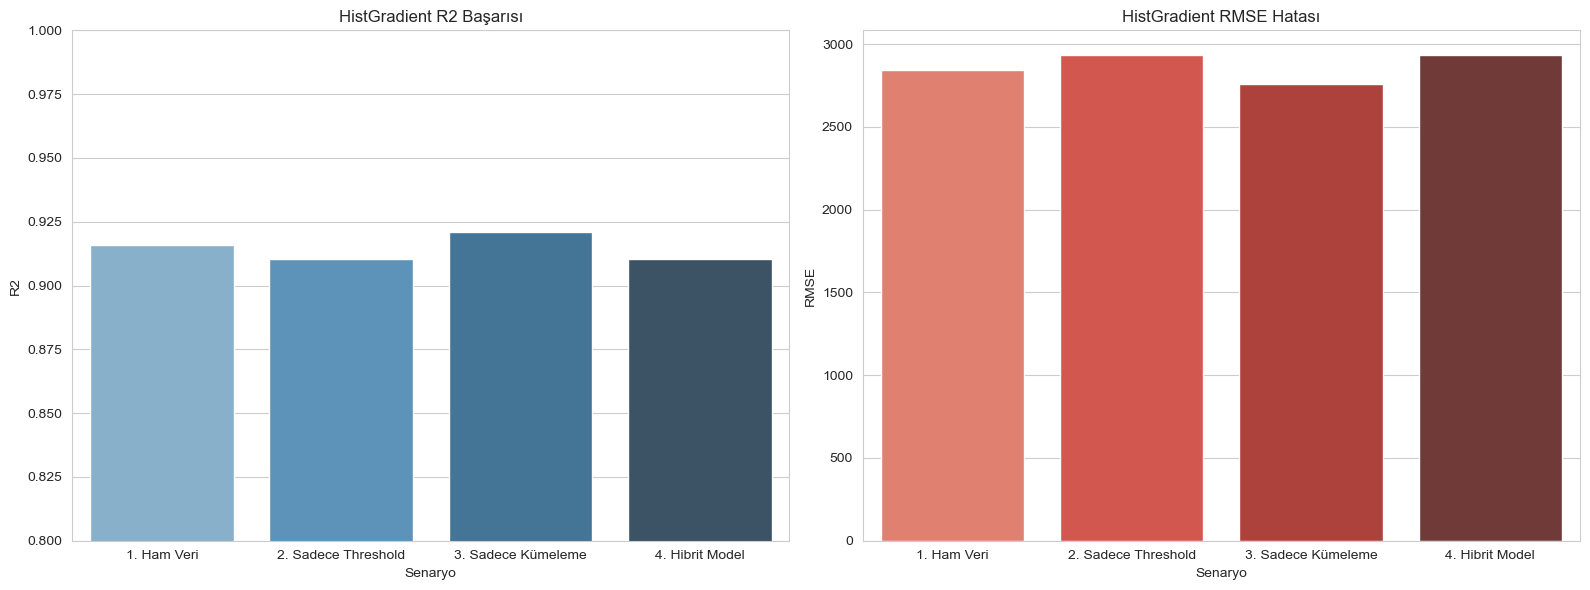

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Senaryo', y='R2', data=df_sonuc, ax=axes[0], palette='Blues_d')
axes[0].set_title('HistGradient R2 Başarısı')
axes[0].set_ylim(0.8, 1.0)

sns.barplot(x='Senaryo', y='RMSE', data=df_sonuc, ax=axes[1], palette='Reds_d')
axes[1].set_title('HistGradient RMSE Hatası')

plt.tight_layout()
plt.show()